# Final figures — TES vs MKID comparison

Publication-quality figures built **from the stored results** (`results/<DET>/bkg-<bg>/.../flux.csv`)
produced by `main_Refined.ipynb` / `examples/save_all.py`. No re-optimization here — we only
read the saved best-fit flux and overlay it.

For a fixed **mediator** (`q0` heavy / `q2` light) and **scenario** (Halo / mixture / Bound),
each DM mass gets its **own figure file** overlaying the TES and MKID recovered flux against the
input η(v_min). The energy-bin count per detector is a function argument (`tes_nbins`, `mkid_nbins`),
so you can compare at a common R5 or at each detector's fine binning (TES R10 / MKID R9).

**Output layout** — each figure is saved under a self-describing hierarchy:

```
results/final/<scenario>/<heavy|light>/<binning>/M<mass>.pdf
```
- `<scenario>` : `Halo`, `mix5`, `mix25`, `Bound`
- `<heavy|light>` : mediator (q0 = heavy, q2 = light)
- `<binning>` : `R5` when both detectors share the bin count, else `TES-R<n>_MKID-R<m>`
- `<mass>` : `M1` (10 MeV), `M2` (100 MeV), `M3` (1 GeV)


In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

from quantum_sensor.plotting import RESULTS_DIR
from quantum_sensor.constants import CM, DM_MASS
from quantum_sensor.eta_models import eta as eta_model

# Physical Review house style (serif / Computer Modern fonts via mathtext).
plt.style.use(str(RESULTS_DIR.parent / "physrev.mplstyle"))

# eta / flux are stored in natural units (dimension 1/length); 1 natural unit = CM cm^-1.
ETA_TO_CM_INV = CM

MASS_LABELS = {"1": "10 MeV", "2": "100 MeV", "3": "1 GeV"}
MATERIAL    = {"TES": "Al", "MKID": "TiN"}
# Distinct, colour-blind-friendly styles per detector.
STYLE = {
    "TES":  dict(color="tab:red",  lw=5, marker=None),
    "MKID": dict(color="tab:blue", lw=2, marker=None),
}
OUTDIR = RESULTS_DIR / "final"

In [2]:
def _config_tag(material, q, mass, nbins, eta, disk_fraction):
    """Folder name of one stored run (mirrors quantum_sensor.plotting._config_tag)."""
    eta_tag = eta if disk_fraction is None else f"mix{round(disk_fraction * 100)}"
    return f"{material}_q{q}_M{mass}_R{nbins}_{eta_tag}"


def load_flux(detector, q, mass, nbins, eta, disk_fraction=None, background="none"):
    """Read a stored best-fit flux.csv. Returns a structured array or None if absent."""
    material = MATERIAL[detector]
    tag = _config_tag(material, q, mass, nbins, eta, disk_fraction)
    path = RESULTS_DIR / detector / f"bkg-{background}" / tag / "flux.csv"
    if not path.exists():
        return None
    return np.genfromtxt(path, delimiter=",", names=True)


def reference_eta(eta, mass, disk_fraction, vg):
    """Input η(v_min) [cm^-1] over the full axis, matching the fit's scenario.

    mixture -> (1-p)·SHM + p·pure-disk ; Bound -> SHM + bound ; else the pure model.
    """
    mchi = DM_MASS[mass]
    halo = eta_model("Halo", mchi, vg) * ETA_TO_CM_INV
    if disk_fraction is not None:
        disk = eta_model("Disk", mchi, vg) * ETA_TO_CM_INV
        return (1 - disk_fraction) * halo + disk_fraction * disk, \
               rf"SHM ({round((1 - disk_fraction) * 100)} %) + Dark Disk ({round(disk_fraction * 100)} %)"
    if eta == "Bound":
        bound = eta_model("Bound", mchi, vg) * ETA_TO_CM_INV
        return halo + bound, r"SHM + Earth-Bound DM"
    return eta_model(eta, mchi, vg) * ETA_TO_CM_INV, r"SHM"

In [3]:
def final_figure(q, eta, mass, disk_fraction=None, tes_nbins=5, mkid_nbins=5,
                 background="none", save=True, outdir=OUTDIR, ax=None):
    """One figure overlaying TES and MKID best-fit flux for a single DM mass.

    Fixed mediator ``q`` and scenario (``eta`` + ``disk_fraction``); the energy-bin
    count is chosen per detector (``tes_nbins`` / ``mkid_nbins``). Reads the stored
    flux.csv -- nothing is re-optimized.
    """
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Reference η over the full 1-800 km/s axis (analytic, matches the windowed CSV).
    vg = np.logspace(0.0, np.log10(800.0), 600)
    ref, ref_label = reference_eta(eta, mass, disk_fraction, vg)

    # On a linear y-axis, normalize everything by the order of magnitude of the
    # peak η and show that order in the axis label (instead of matplotlib's corner
    # offset). Bound keeps absolute values on its log axis.
    linear_y = not (eta == "Bound" and disk_fraction is None)
    if linear_y:
        peak = float(np.nanmax(ref))
        y_exp = int(np.floor(np.log10(peak))) if peak > 0 else 0
        norm = 10.0 ** y_exp
        y_label = rf"$\widetilde{{\eta}}\ [10^{{{y_exp}}}\,\mathrm{{cm}}^{{-1}}]$"
    else:
        norm = 1.0
        y_label = r"$\widetilde{\eta}\ [\mathrm{cm}^{-1}]$"

    ax.plot(vg, ref / norm, color="0.35", lw=2.0, ls="-", label=ref_label, zorder=1)

    nbins = {"TES": tes_nbins, "MKID": mkid_nbins}
    windows = {}                       # per-detector v_min span, for the bars below
    for det in ("TES", "MKID"):
        d = load_flux(det, q, mass, nbins[det], eta, disk_fraction, background)
        if d is None:
            print(f"  skip {det}: no stored flux for q{q} M{mass} R{nbins[det]} "
                  f"{eta}{'' if disk_fraction is None else f' mix{round(disk_fraction*100)}'}")
            continue
        flux = np.atleast_1d(d["flux"]) * ETA_TO_CM_INV
        lo, hi = np.atleast_1d(d["vmin_low"]), np.atleast_1d(d["vmin_high"])
        ax.hlines(flux / norm, lo, hi, lw=STYLE[det]["lw"], zorder=3,
                  label=f"{det}", color=STYLE[det]["color"])
        windows[det] = (float(lo.min()), float(hi.max()))

    # Each detector's effective v_min window drawn as a |----| span near the
    # bottom of the panel (x in data coords, y in axes fraction), colour-matched
    # to its staircase so the covered range is read at a glance.
    trans = ax.get_xaxis_transform()
    ybar = {"TES": 0.085, "MKID": 0.035}
    for det, (wlo, whi) in windows.items():
        y = ybar[det]
        col = STYLE[det]["color"]
        # dashed connecting line ...
        ax.plot([wlo, whi], [y, y], transform=trans, color=col,
                ls="--", lw=1.6, clip_on=False, zorder=4)
        # ... but solid end caps  |----|
        ax.plot([wlo, whi], [y, y], transform=trans, color=col,
                ls="none", marker="|", ms=9, mew=1.6, clip_on=False, zorder=4)
    if windows:
        # label sits directly above the TES window bar (first available otherwise)
        det_lbl = "TES" if "TES" in windows else next(iter(windows))
        wlo, whi = windows[det_lbl]
        ax.text((wlo * whi) ** 0.5, ybar[det_lbl] + 0.015, r"$v_{\text{min}}$ window",
                transform=trans, fontsize=18, color="0.25", va="bottom", ha="center")

    ax.set_xscale("log")
    if eta == "Bound" and disk_fraction is None:
        ax.set_yscale("log")           # Bound η spans many decades over a few km/s
    ax.set_xlim(1.0, 800.0)
    ax.set_xlabel(r"$v_{\text{min}}$ [km s$^{-1}$]", fontsize=30)
    ax.set_ylabel(y_label, fontsize=30)
    mediator = {"0": "Heavy", "2": "Light"}.get(q, f"q{q}")
    ax.set_title(rf"$m_\chi$ = {MASS_LABELS[mass]}, {mediator} mediator", fontsize=25)
    ax.xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    ax.tick_params(axis="both", which="major", labelsize=23)
    ax.tick_params(axis="both", which="minor", labelsize=23)
    ax.legend(loc="lower left", fontsize=15, frameon=False)
    ax.grid(True, which="both", ls="--", alpha=0.35)
    if not (eta == "Bound" and disk_fraction is None):
        ax.set_ylim(bottom=0.0)          # flux/eta are non-negative

    if save:
        # Clear hierarchy: final/<scenario>/<heavy|light>/<binning>/M<mass>.pdf
        scenario = eta if disk_fraction is None else f"mix{round(disk_fraction * 100)}"
        binning = (f"R{tes_nbins}" if tes_nbins == mkid_nbins
                   else f"TES-R{tes_nbins}_MKID-R{mkid_nbins}")
        dest = outdir / scenario / mediator.lower() / binning
        dest.mkdir(parents=True, exist_ok=True)
        path = dest / f"M{mass}.pdf"
        plt.savefig(path, bbox_inches="tight")
        print(f"  saved {path.relative_to(RESULTS_DIR.parent)}")
    if own:
        plt.show()
    return ax


def final_all(q, eta, masses=("1", "2", "3"), **kw):
    """Produce one separate figure FILE per DM mass (per the chosen layout)."""
    for mass in masses:
        final_figure(q, eta, mass, **kw)

## Halo (SHM) — common R5 comparison

### Heavy mediator (q0)

  saved results/final/Halo/heavy/R5/M1.pdf


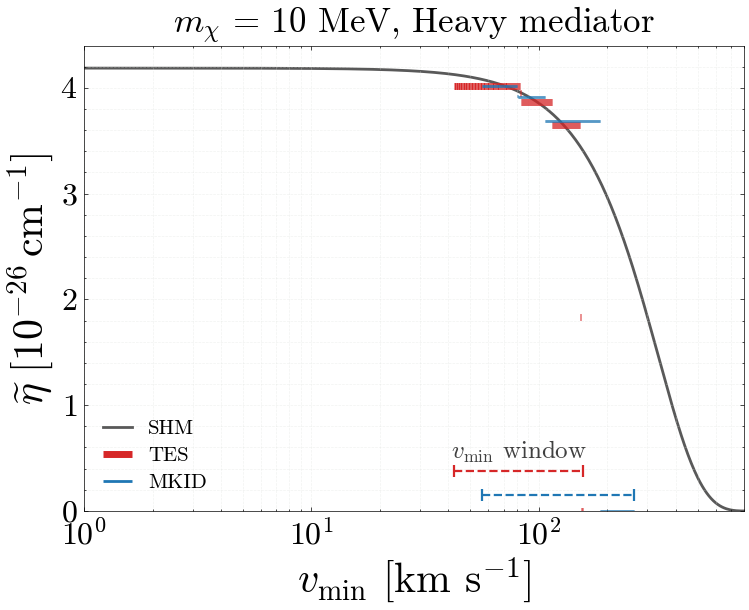

  saved results/final/Halo/heavy/R5/M2.pdf


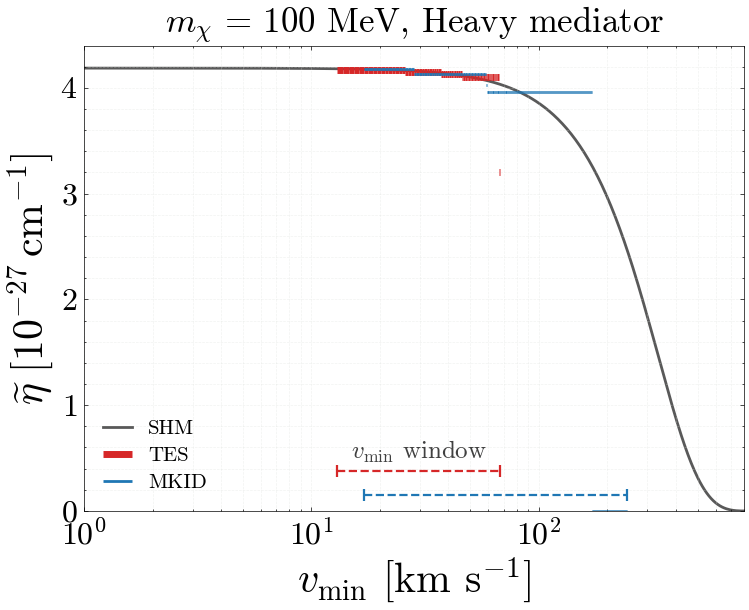

  saved results/final/Halo/heavy/R5/M3.pdf


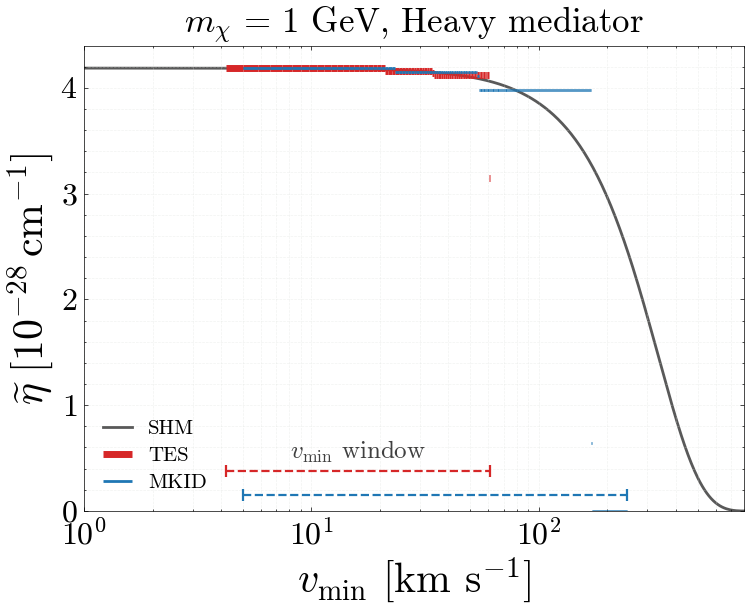

In [4]:
final_all(q='0', eta='Halo')

### Light mediator (q2)

  saved results/final/Halo/light/R5/M1.pdf


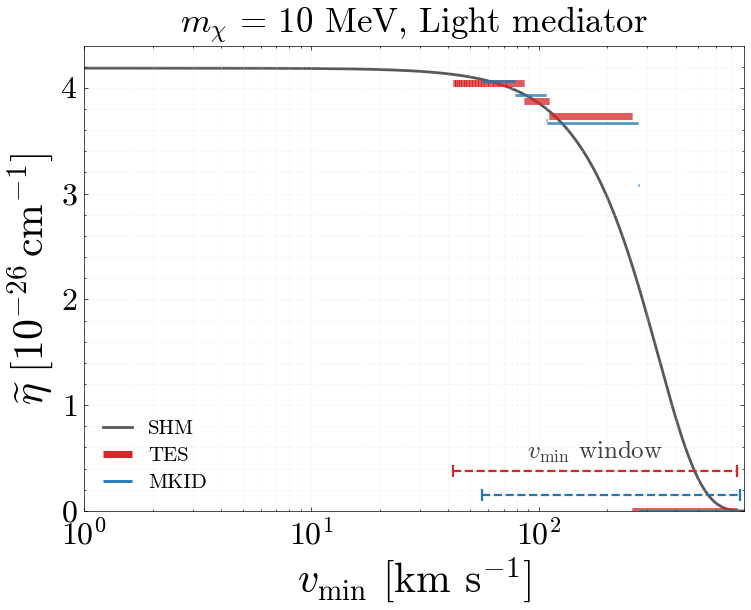

  saved results/final/Halo/light/R5/M2.pdf


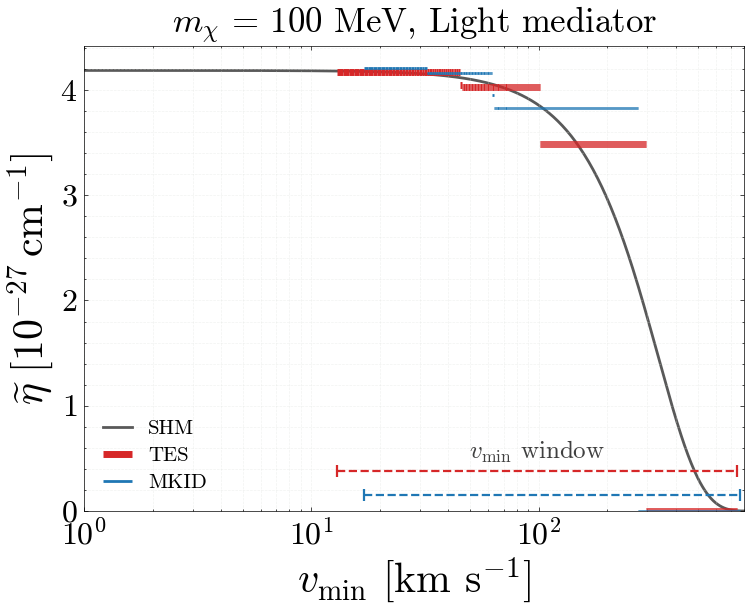

  saved results/final/Halo/light/R5/M3.pdf


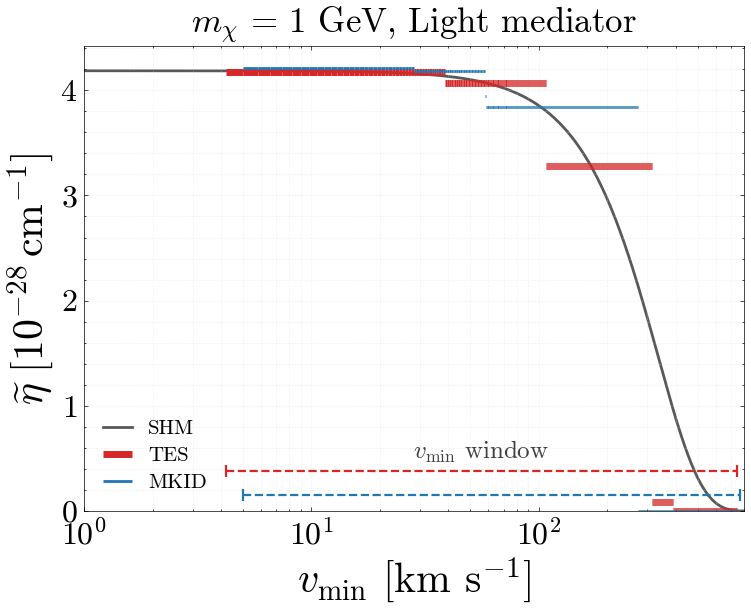

In [5]:
final_all(q='2', eta='Halo')

## Halo (SHM) — each detector's fine binning (TES R10 / MKID R9)

### Heavy mediator (q0)

  saved results/final/Halo/heavy/TES-R10_MKID-R9/M1.pdf


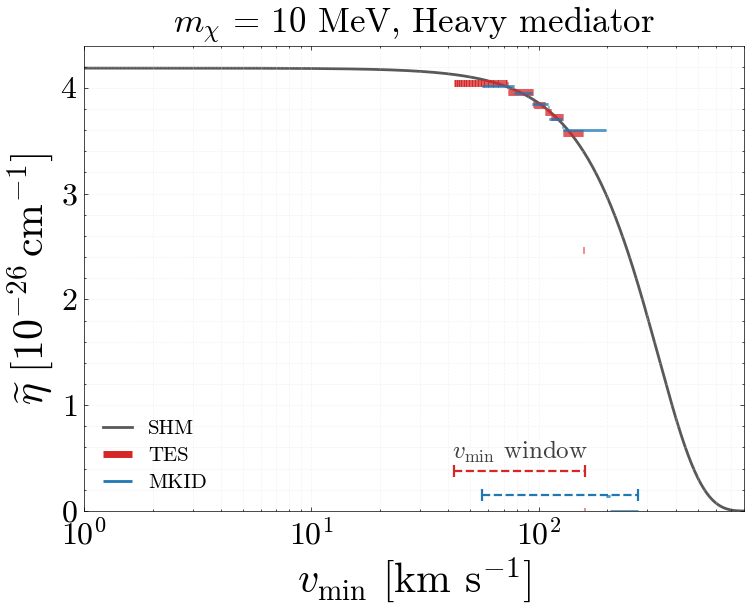

  saved results/final/Halo/heavy/TES-R10_MKID-R9/M2.pdf


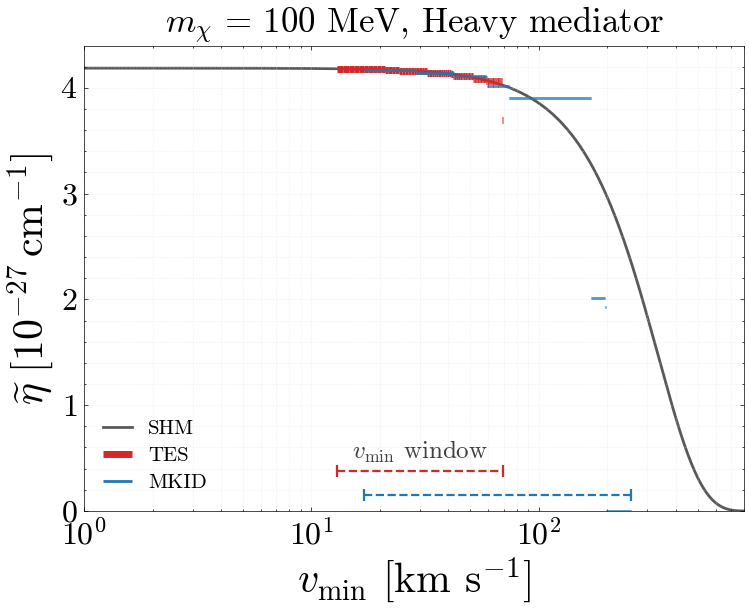

  saved results/final/Halo/heavy/TES-R10_MKID-R9/M3.pdf


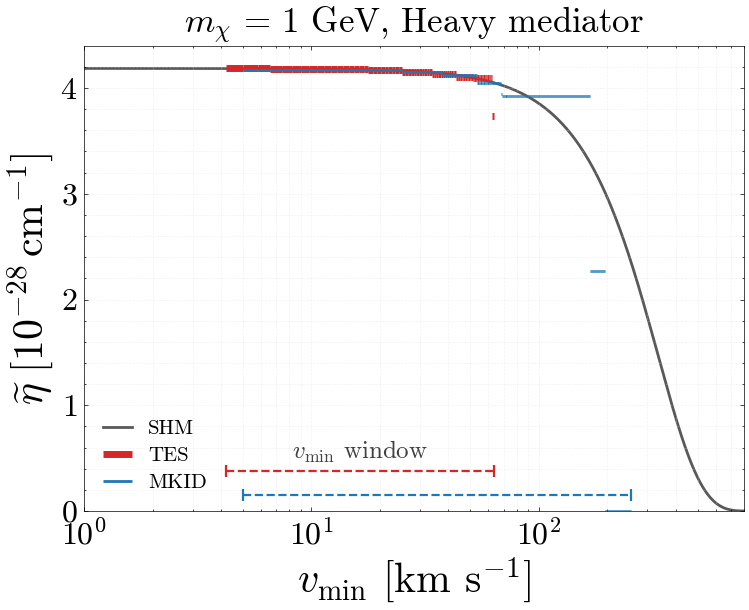

In [6]:
final_all(q='0', eta='Halo', tes_nbins=10, mkid_nbins=9)

### Light mediator (q2)
MKID q2 R9 must be generated first; it is skipped with a note if absent.

  saved results/final/Halo/light/TES-R10_MKID-R9/M1.pdf


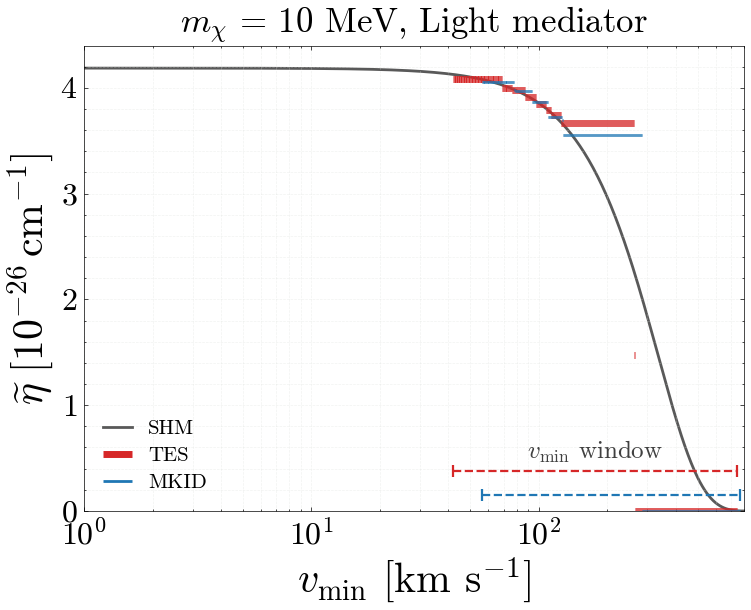

  skip MKID: no stored flux for q2 M2 R9 Halo


  saved results/final/Halo/light/TES-R10_MKID-R9/M2.pdf


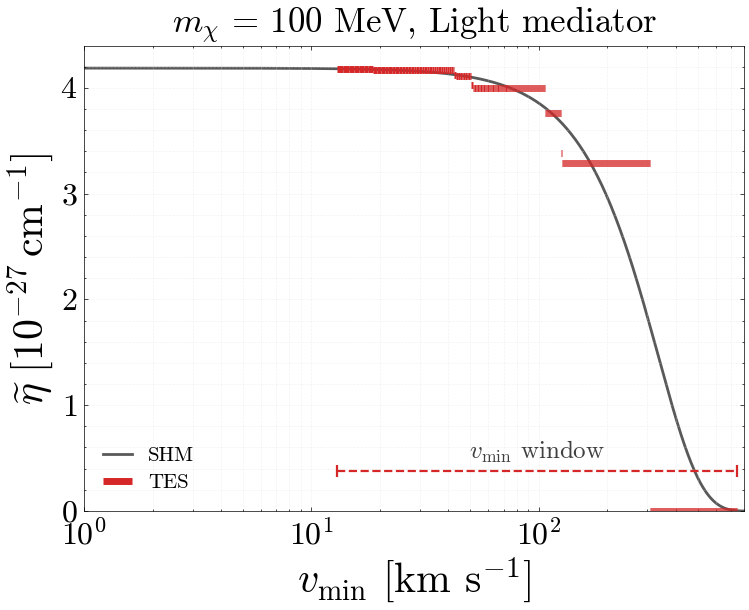

  skip MKID: no stored flux for q2 M3 R9 Halo


  saved results/final/Halo/light/TES-R10_MKID-R9/M3.pdf


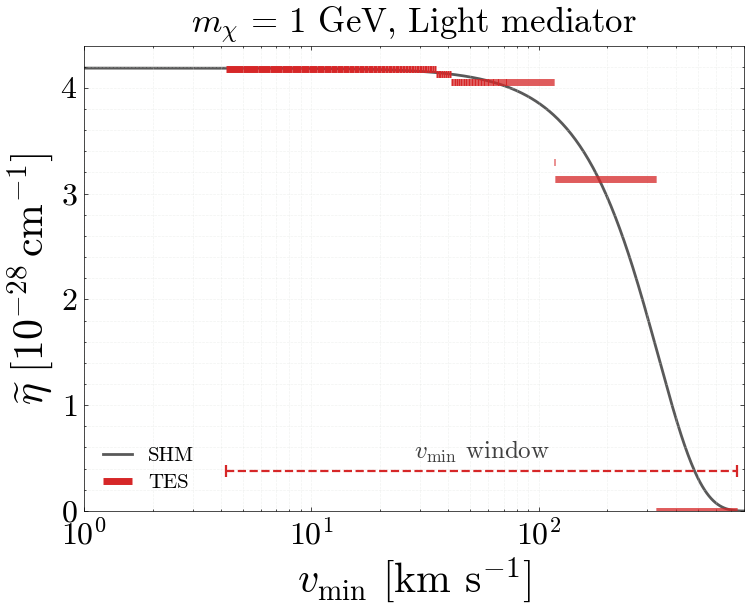

In [7]:
final_all(q='2', eta='Halo', tes_nbins=10, mkid_nbins=9)

## Mixture (best-fit) — dark-disk fraction, R5

### Heavy mediator (q0), 5% disk

  saved results/final/mix5/heavy/R5/M1.pdf


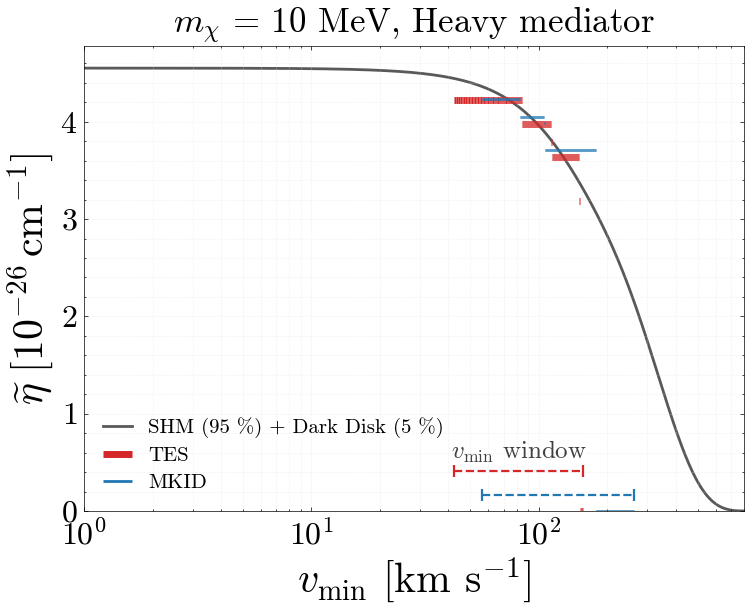

  saved results/final/mix5/heavy/R5/M2.pdf


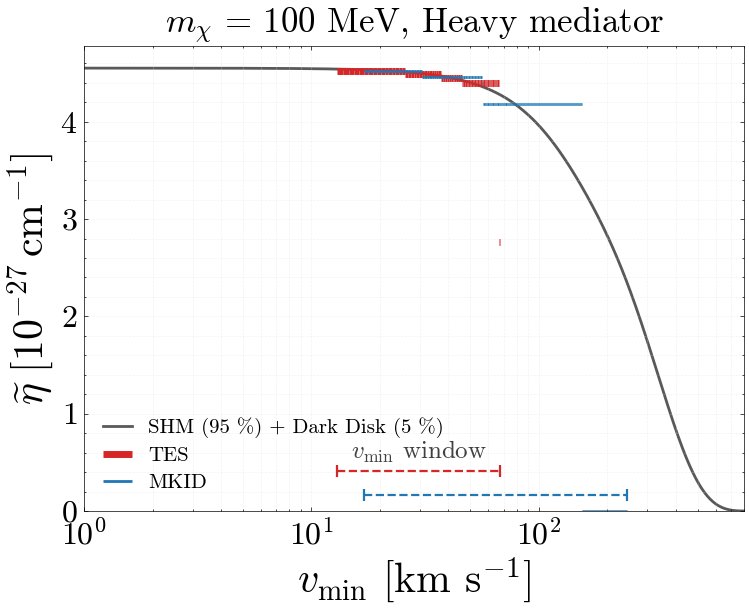

  saved results/final/mix5/heavy/R5/M3.pdf


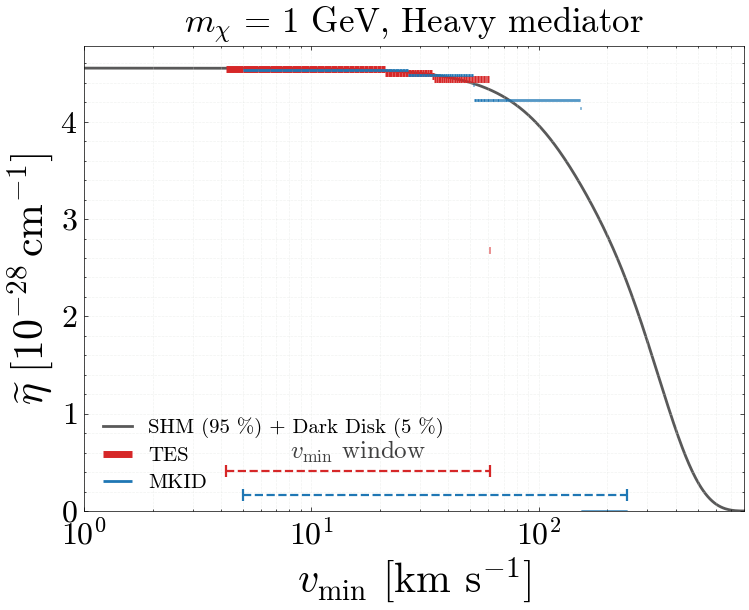

In [8]:
final_all(q='0', eta='Halo', disk_fraction=0.05)

### Heavy mediator (q0), 25% disk

  saved results/final/mix25/heavy/R5/M1.pdf


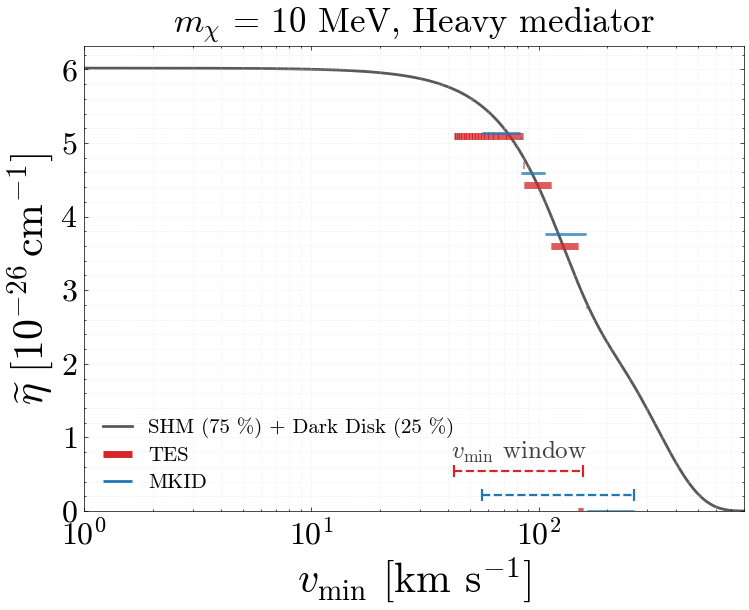

  saved results/final/mix25/heavy/R5/M2.pdf


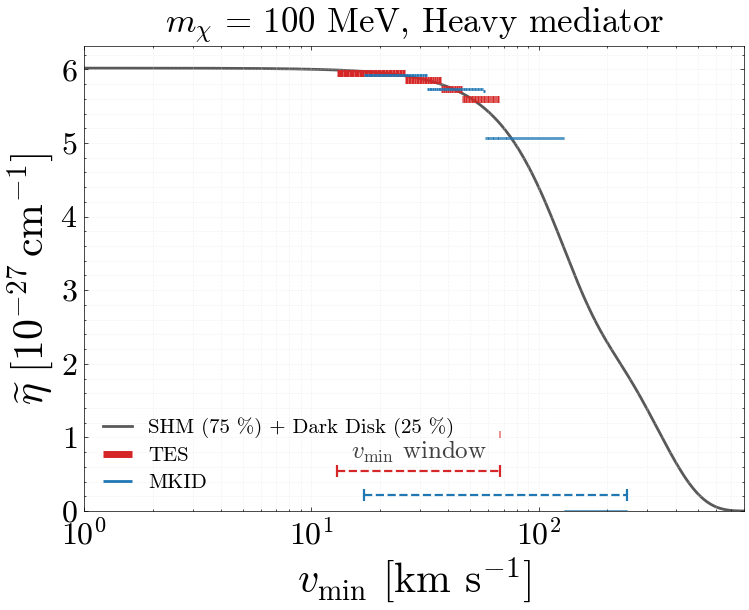

  saved results/final/mix25/heavy/R5/M3.pdf


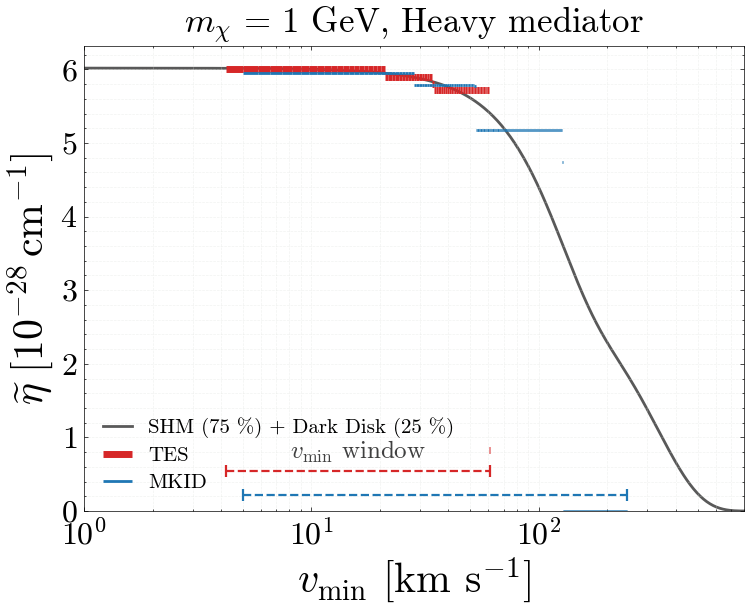

In [9]:
final_all(q='0', eta='Halo', disk_fraction=0.25)

### Light mediator (q2), 5% disk

  saved results/final/mix5/light/R5/M1.pdf


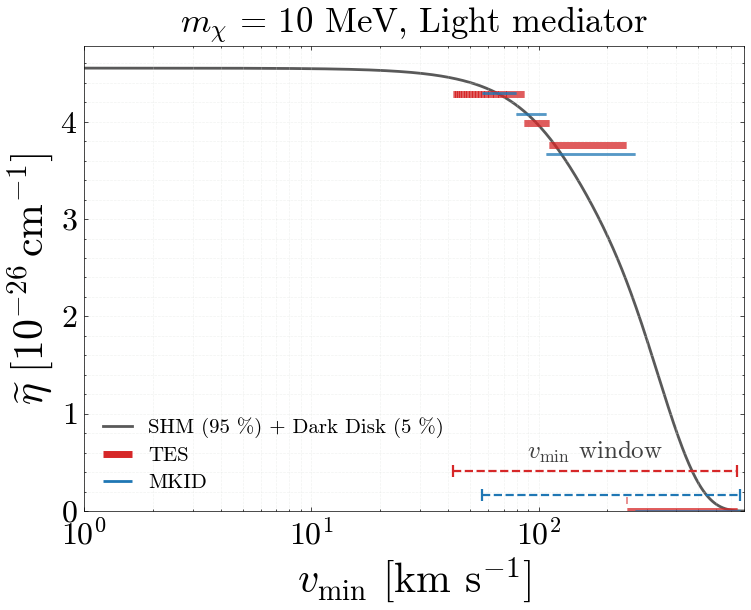

  saved results/final/mix5/light/R5/M2.pdf


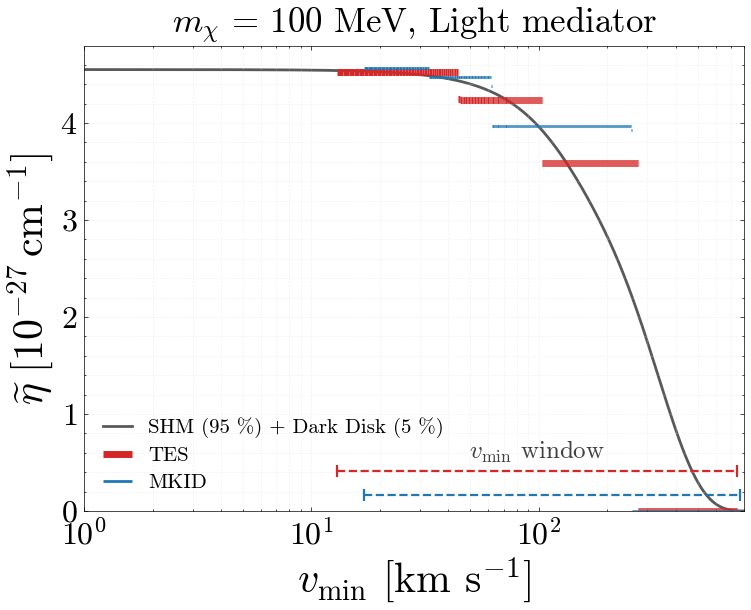

  saved results/final/mix5/light/R5/M3.pdf


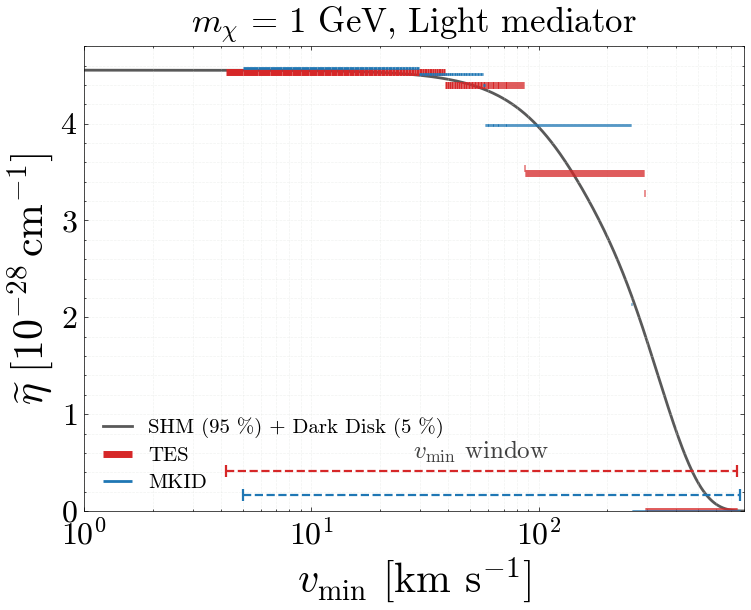

In [10]:
final_all(q='2', eta='Halo', disk_fraction=0.05)

### Light mediator (q2), 25% disk

  saved results/final/mix25/light/R5/M1.pdf


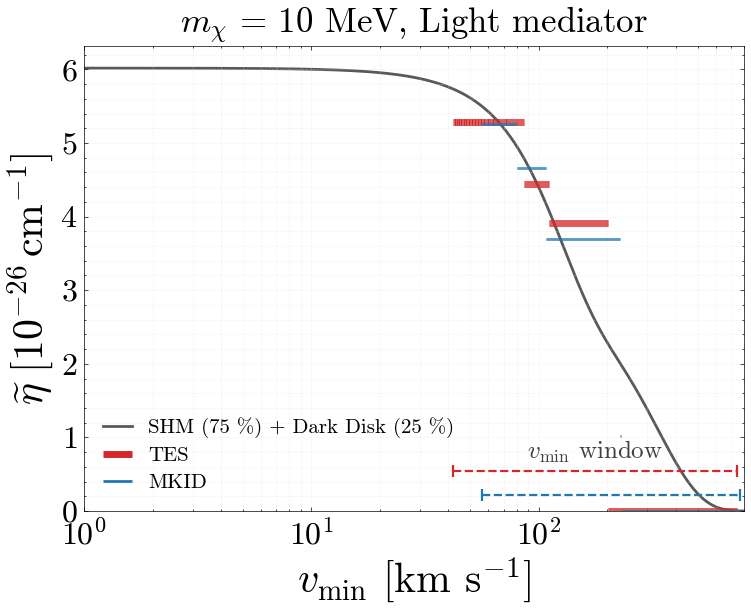

  saved results/final/mix25/light/R5/M2.pdf


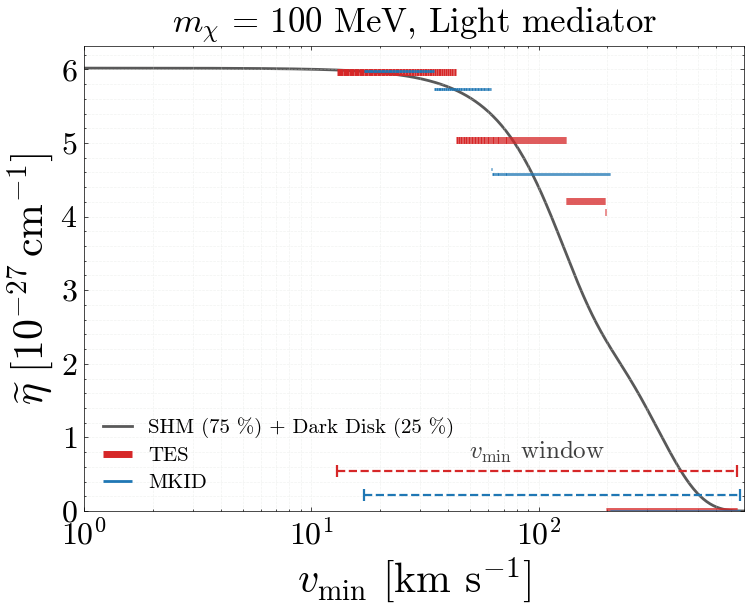

  saved results/final/mix25/light/R5/M3.pdf


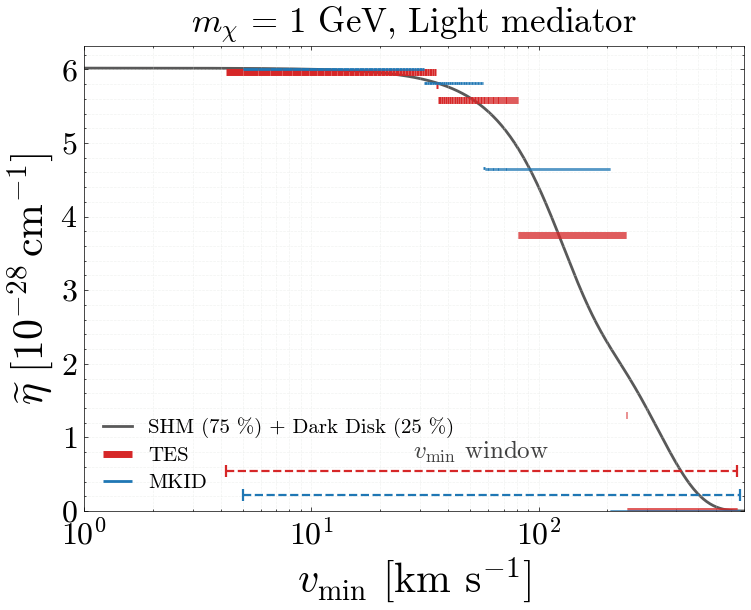

In [11]:
final_all(q='2', eta='Halo', disk_fraction=0.25)

## Mixture (best-fit) — dark-disk fraction each detector's fine binning (TES R10 / MKID R9)

### Heavy mediator (q0), 5% disk

  saved results/final/mix5/heavy/TES-R10_MKID-R9/M1.pdf


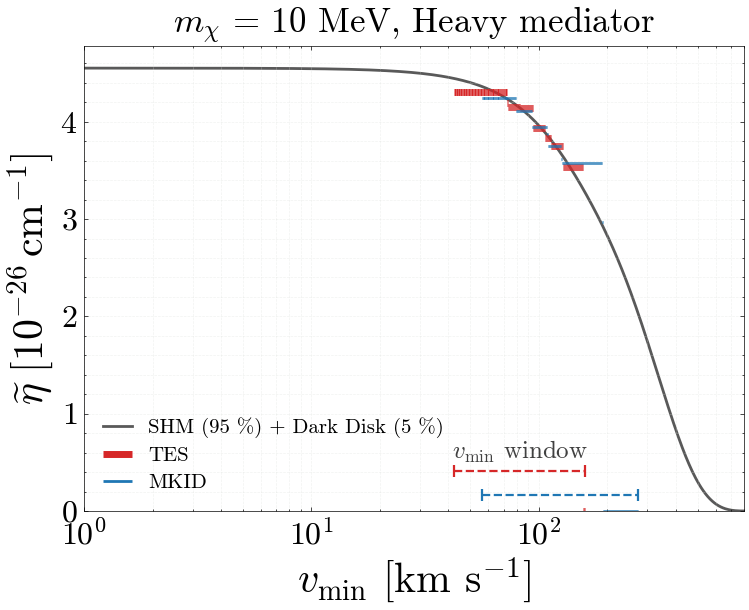

  saved results/final/mix5/heavy/TES-R10_MKID-R9/M2.pdf


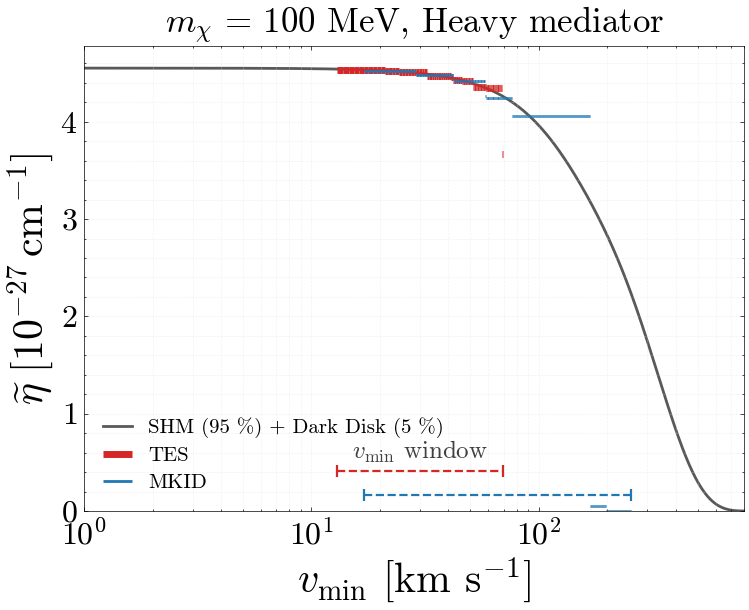

  saved results/final/mix5/heavy/TES-R10_MKID-R9/M3.pdf


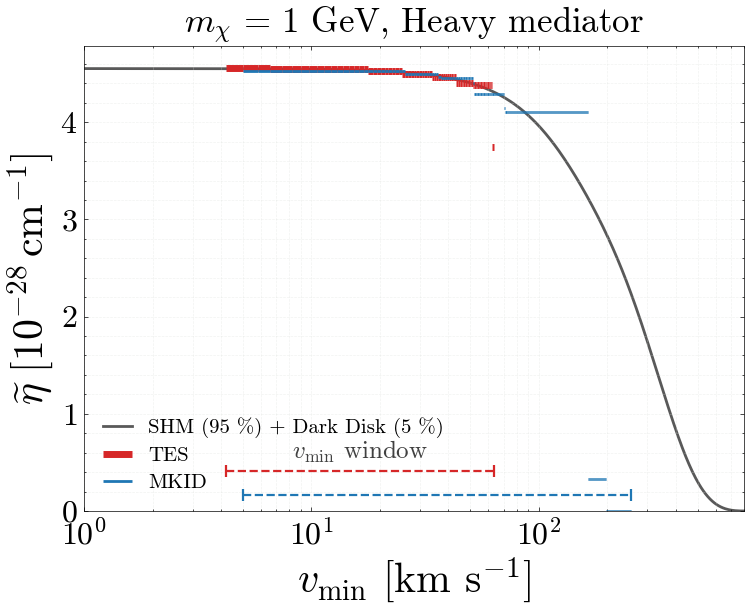

In [12]:
final_all(q='0', eta='Halo', disk_fraction=0.05, tes_nbins=10, mkid_nbins=9)

### Heavy mediator (q0), 25% disk

  saved results/final/mix25/heavy/TES-R10_MKID-R9/M1.pdf


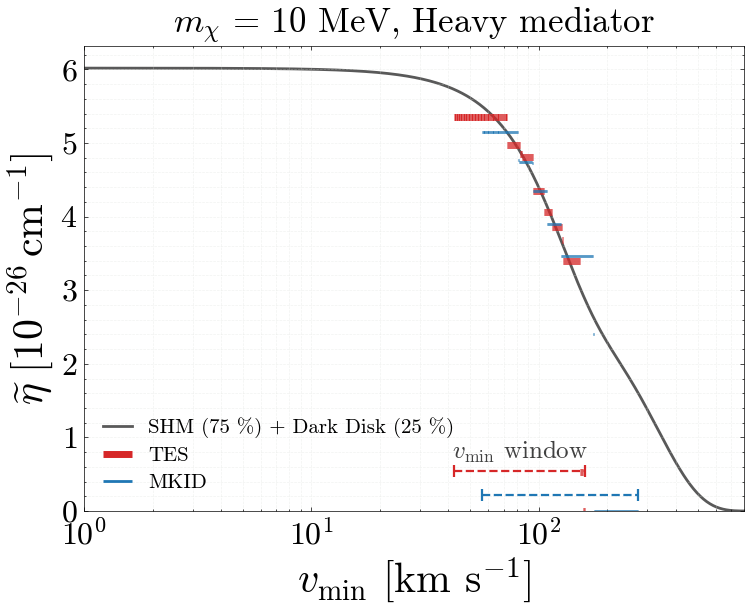

  saved results/final/mix25/heavy/TES-R10_MKID-R9/M2.pdf


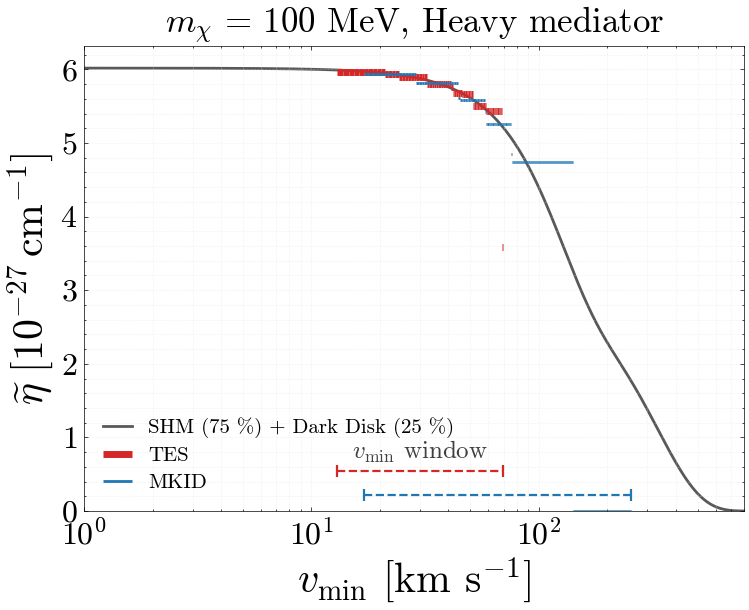

  saved results/final/mix25/heavy/TES-R10_MKID-R9/M3.pdf


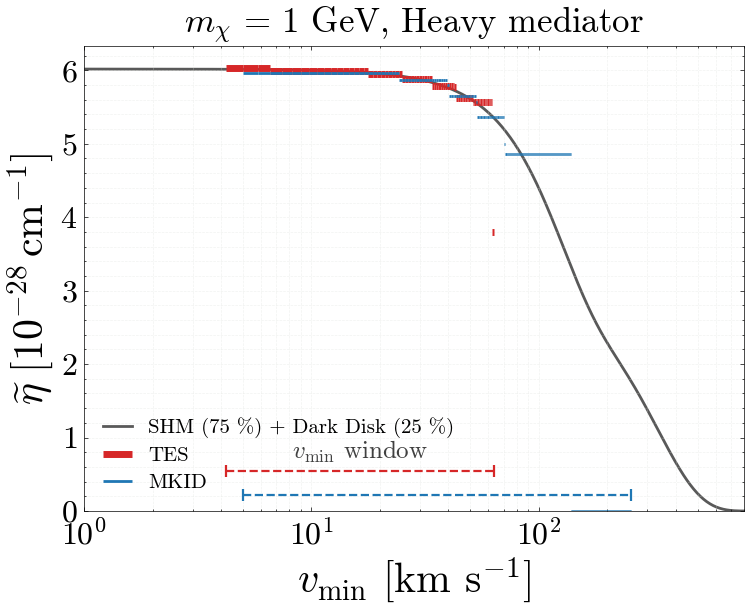

In [13]:
final_all(q='0', eta='Halo', disk_fraction=0.25, tes_nbins=10, mkid_nbins=9)

### Light mediator (q2), 5% disk

  saved results/final/mix5/light/TES-R10_MKID-R9/M1.pdf


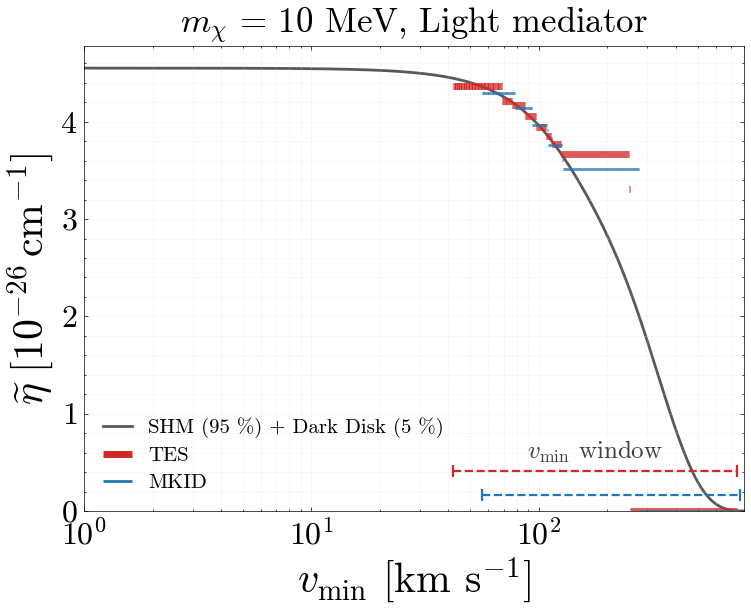

  skip MKID: no stored flux for q2 M2 R9 Halo mix5


  saved results/final/mix5/light/TES-R10_MKID-R9/M2.pdf


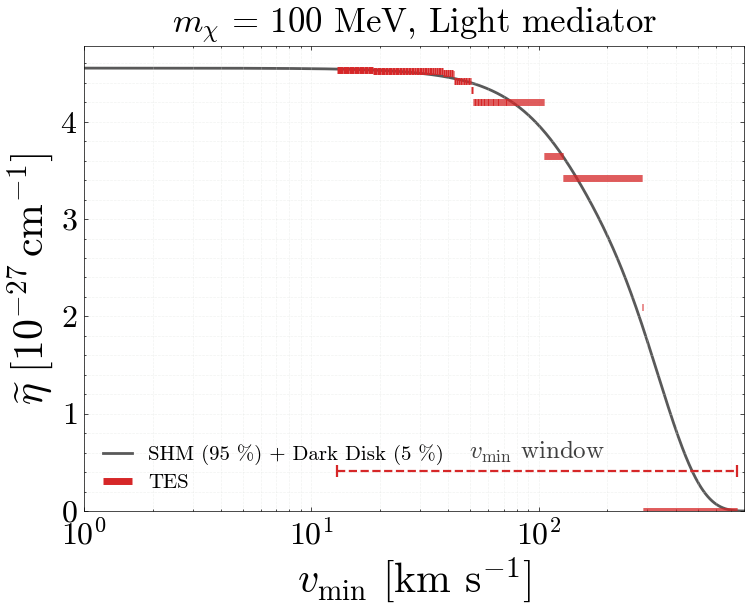

  skip MKID: no stored flux for q2 M3 R9 Halo mix5


  saved results/final/mix5/light/TES-R10_MKID-R9/M3.pdf


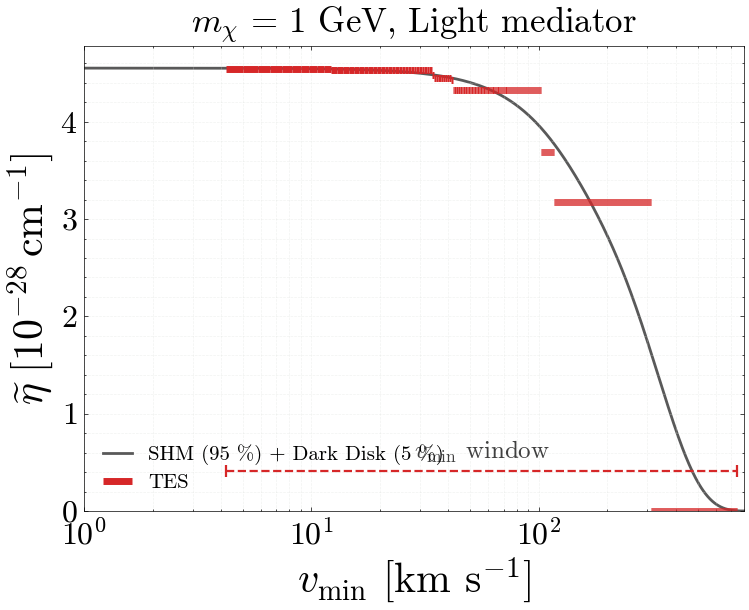

In [14]:
final_all(q='2', eta='Halo', disk_fraction=0.05, tes_nbins=10, mkid_nbins=9)

### Light mediator (q2), 25% disk

  saved results/final/mix25/light/TES-R10_MKID-R9/M1.pdf


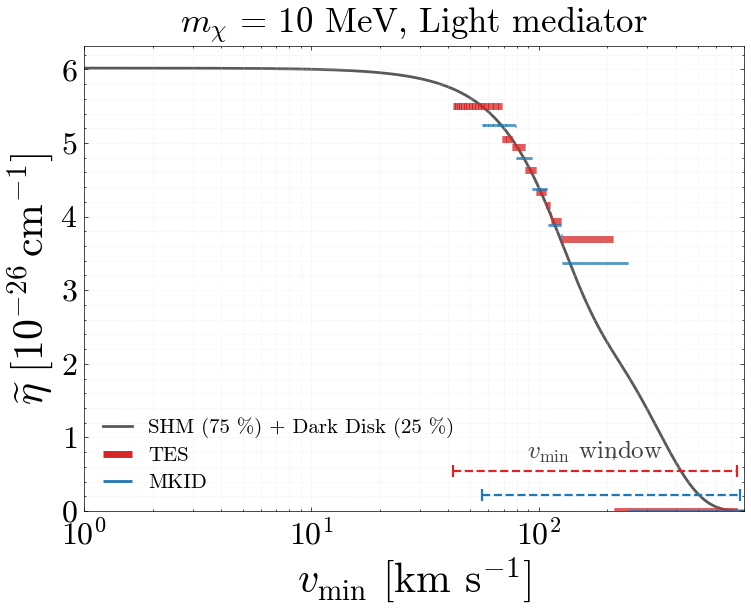

  skip MKID: no stored flux for q2 M2 R9 Halo mix25


  saved results/final/mix25/light/TES-R10_MKID-R9/M2.pdf


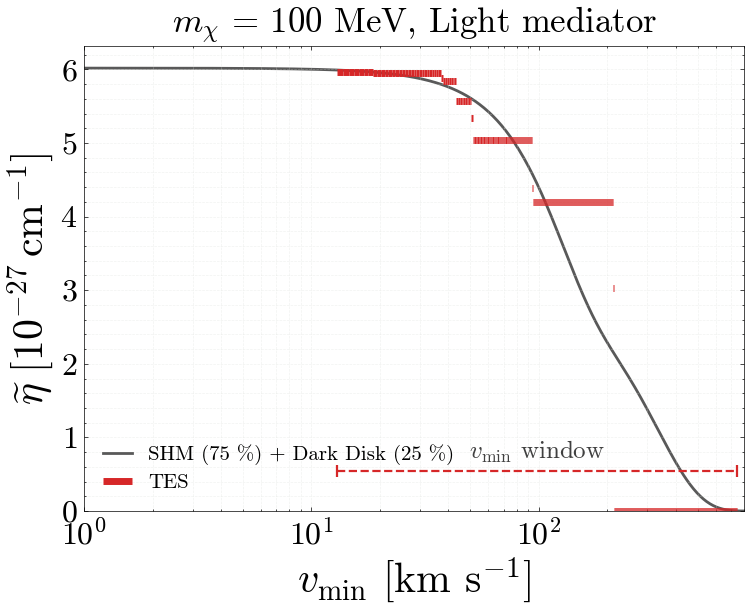

  skip MKID: no stored flux for q2 M3 R9 Halo mix25


  saved results/final/mix25/light/TES-R10_MKID-R9/M3.pdf


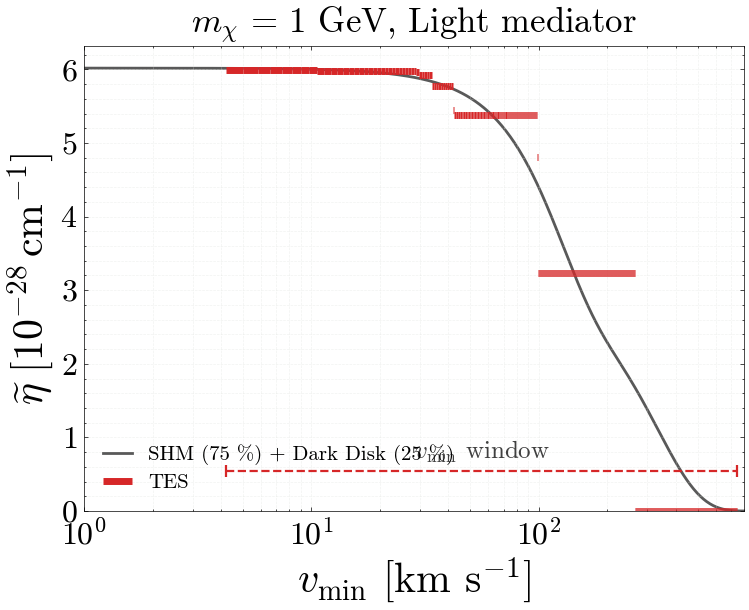

In [15]:
final_all(q='2', eta='Halo', disk_fraction=0.25, tes_nbins=10, mkid_nbins=9)

## Bound (Earth-bound thermal DM) — only the heaviest mass (1 GeV) reaches the window

### Heavy mediator (q0), R5

  saved results/final/Bound/heavy/R5/M3.pdf


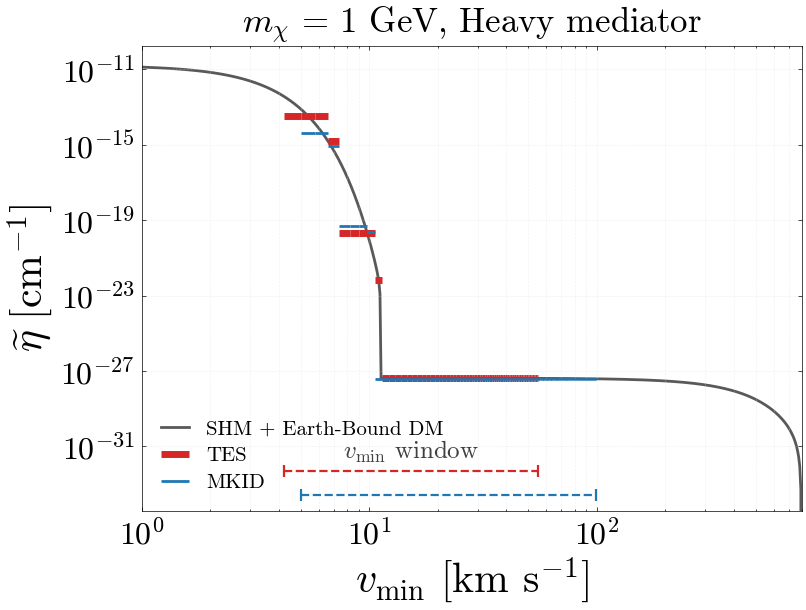

<Axes: title={'center': '$m_\\chi$ = 1 GeV, Heavy mediator'}, xlabel='$v_{\\text{min}}$ [km s$^{-1}$]', ylabel='$\\widetilde{\\eta}\\ [\\mathrm{cm}^{-1}]$'>

In [16]:
final_figure(q='0', eta='Bound', mass='3')

### Light mediator (q2), R5

  saved results/final/Bound/light/R5/M3.pdf


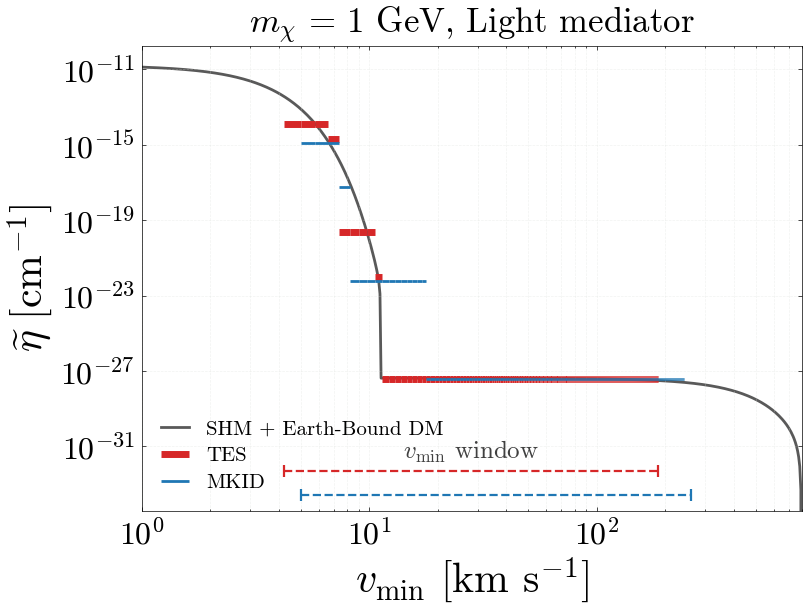

<Axes: title={'center': '$m_\\chi$ = 1 GeV, Light mediator'}, xlabel='$v_{\\text{min}}$ [km s$^{-1}$]', ylabel='$\\widetilde{\\eta}\\ [\\mathrm{cm}^{-1}]$'>

In [17]:
final_figure(q='2', eta='Bound', mass='3')

## Bound (Earth-bound thermal DM) — only the heaviest mass (1 GeV) reaches the window each detector's fine binning (TES R10 / MKID R9)

### Heavy mediator (q0)

  saved results/final/Bound/heavy/TES-R10_MKID-R9/M3.pdf


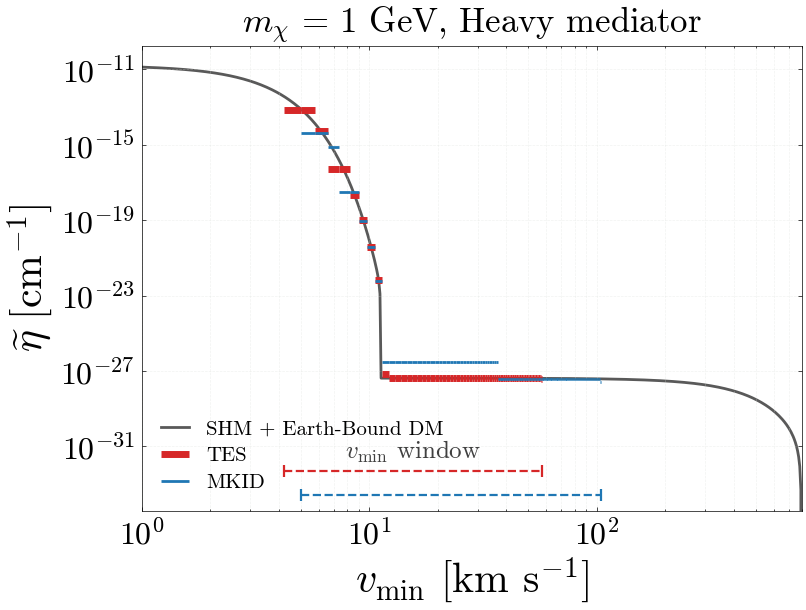

<Axes: title={'center': '$m_\\chi$ = 1 GeV, Heavy mediator'}, xlabel='$v_{\\text{min}}$ [km s$^{-1}$]', ylabel='$\\widetilde{\\eta}\\ [\\mathrm{cm}^{-1}]$'>

In [18]:
final_figure(q='0', eta='Bound', mass='3', tes_nbins=10, mkid_nbins=9)

### Light mediator (q2)

  skip MKID: no stored flux for q2 M3 R9 Bound


  saved results/final/Bound/light/TES-R10_MKID-R9/M3.pdf


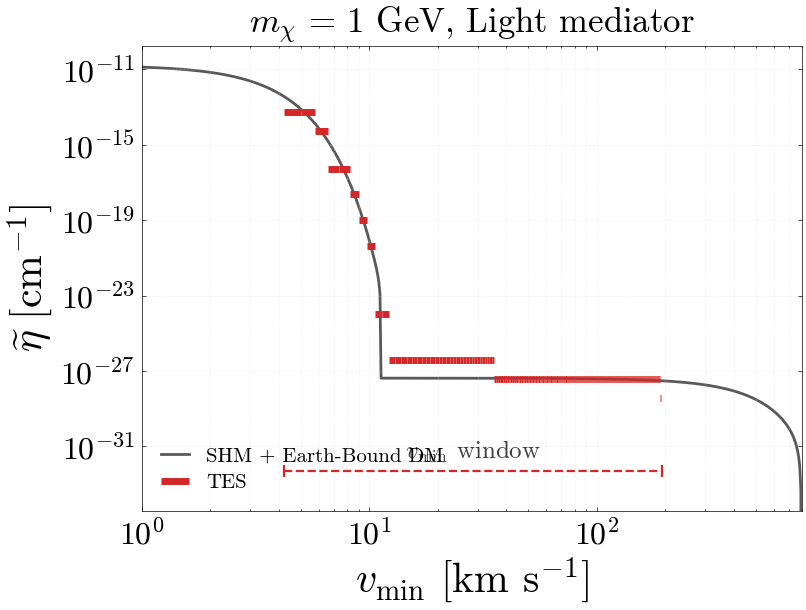

<Axes: title={'center': '$m_\\chi$ = 1 GeV, Light mediator'}, xlabel='$v_{\\text{min}}$ [km s$^{-1}$]', ylabel='$\\widetilde{\\eta}\\ [\\mathrm{cm}^{-1}]$'>

In [19]:
final_figure(q='2', eta='Bound', mass='3', tes_nbins=10, mkid_nbins=9)